<a href="https://colab.research.google.com/github/SenithDamiru/FTMS/blob/main/FTMS_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FTMS – Fuel Tank Depletion Prediction**
*Training the Machine Learning Model to Predict Fuel Tank Depletions*

# INSTALL & IMPORT LIBRARIES

In [ ]:
# ===== ENVIRONMENT LOCK =====
!pip install -q numpy==1.26.4
!pip install -q scikit-learn==1.6.1
!pip install -q xgboost==3.1.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 40.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost openpyxl

import pandas as pd
import numpy as np
print(np.__version__)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# For saving models
import pickle

print("✓ Libraries imported successfully!")

1.26.4
✓ Libraries imported successfully!


# 1.Load Data

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"Dataset loaded: {df.shape}")
df.head()


Saving FTMS_Dataset.csv to FTMS_Dataset.csv
Dataset loaded: (936, 7)


,LogID,TankID,FuelType,LoadDate,QuantityLoaded,StockBefore,StockAfter
0,1,1P,92 Petrol,2023-01-01,6600,4109,10709
1,2,2P,92 Petrol,2023-01-01,6000,2062,8062
2,3,3P,95 Petrol,2023-01-01,3000,3261,6261
3,4,1AD,Auto Diesel,2023-01-02,12000,5572,17572
4,5,1SD,Super Diesel,2023-01-03,6000,2364,8364


# 2.Data Preparation

## 2.1 Convert Date & Sort Data

In [ ]:
df["LoadDate"] = pd.to_datetime(df["LoadDate"])
df = df.sort_values(["TankID", "LoadDate"]).reset_index(drop=True)


## 2.2 Feature Creation

In [ ]:
# Time-based features
df["Month"] = df["LoadDate"].dt.month
df["DayOfWeek"] = df["LoadDate"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
df["Quarter"] = df["LoadDate"].dt.quarter


## 2.3 Tank Capacity Mapping

In [ ]:
tank_capacities = {
    "1P": 14490,
    "2P": 9000,
    "3P": 9000,
    "1AD": 25000,
    "1SD": 9000
}

df["Capacity"] = df["TankID"].map(tank_capacities)


## 2.4 Consumption Calculation

In [ ]:
df["NextLoadDate"] = df.groupby("TankID")["LoadDate"].shift(-1)
df["NextStockBefore"] = df.groupby("TankID")["StockBefore"].shift(-1)

df["DaysBetween"] = (df["NextLoadDate"] - df["LoadDate"]).dt.days
df["FuelConsumed"] = df["StockAfter"] - df["NextStockBefore"]
df["DailyConsumption"] = df["FuelConsumed"] / df["DaysBetween"]


## 2.5 Data Cleaning

In [ ]:
df_clean = df.copy()

df_clean = df_clean[df_clean["DaysBetween"] > 0]
df_clean = df_clean[df_clean["DailyConsumption"] > 0]
df_clean = df_clean[df_clean["DailyConsumption"] < 5000]

df_clean = df_clean.dropna()


In [ ]:
print(f" Clean records: {len(df_clean)}")

 Clean records: 931


#3.Data Separation (Per Tank)

In [ ]:
features = ["Month", "DayOfWeek", "IsWeekend", "Quarter", "Capacity"]
target = "DailyConsumption"


# 4.Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 5.Model Building
Training separate models for each tank.

In [ ]:
models = {}
scalers = {}
metrics = []


# 6.Random Forest Model

In [ ]:
for tank_id in df_clean["TankID"].unique():

    tank_data = df_clean[df_clean["TankID"] == tank_id]
    X = tank_data[features]
    y = tank_data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )

    rf_model.fit(X_train_scaled, y_train)
    y_pred = rf_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    models[(tank_id, "RandomForest")] = rf_model
    scalers[(tank_id, "RandomForest")] = scaler

    metrics.append({
        "Tank": tank_id,
        "Model": "Random Forest",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# 7.XGBoost Model

In [ ]:
for tank_id in df_clean["TankID"].unique():

    tank_data = df_clean[df_clean["TankID"] == tank_id]
    X = tank_data[features]
    y = tank_data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )

    xgb_model.fit(X_train_scaled, y_train)
    y_pred = xgb_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    models[(tank_id, "XGBoost")] = xgb_model
    scalers[(tank_id, "XGBoost")] = scaler

    metrics.append({
        "Tank": tank_id,
        "Model": "XGBoost",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# 8.Gradient Boosting Model

In [ ]:
for tank_id in df_clean["TankID"].unique():

    tank_data = df_clean[df_clean["TankID"] == tank_id]
    X = tank_data[features]
    y = tank_data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    gb_model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )

    gb_model.fit(X_train_scaled, y_train)
    y_pred = gb_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    models[(tank_id, "GradientBoosting")] = gb_model
    scalers[(tank_id, "GradientBoosting")] = scaler

    metrics.append({
        "Tank": tank_id,
        "Model": "Gradient Boosting",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# 9.Model Comparison

In [ ]:
results_df = pd.DataFrame(metrics)
results_df


,Tank,Model,MAE,RMSE,R2
0,1AD,Random Forest,112.574598,143.401032,0.379824
1,1P,Random Forest,61.337983,81.408622,0.084934
2,1SD,Random Forest,25.480869,30.772118,-0.204895
3,2P,Random Forest,47.890788,67.367871,0.230019
4,3P,Random Forest,30.151626,38.554763,0.187807
5,1AD,XGBoost,112.738347,145.464186,0.361850
6,1P,XGBoost,68.938535,104.945166,-0.520676
7,1SD,XGBoost,30.206348,36.575570,-0.702223
8,2P,XGBoost,53.081290,73.039242,0.094921
9,3P,XGBoost,35.325215,43.352882,-0.026926


# 10.Best Model Selection (Lowest MAE)

In [ ]:
best_models = results_df.sort_values("MAE").groupby("Tank").first()
best_models


,Model,MAE,RMSE,R2
Tank,,,,
1AD,Gradient Boosting,111.923316,143.776992,0.376568
1P,Random Forest,61.337983,81.408622,0.084934
1SD,Random Forest,25.480869,30.772118,-0.204895
2P,Random Forest,47.890788,67.367871,0.230019
3P,Random Forest,30.151626,38.554763,0.187807


In [ ]:

model_name_map = {
    "Random Forest": "RandomForest",
    "XGBoost": "XGBoost",
    "Gradient Boosting": "GradientBoosting"
}

# Build tank_models and tank_scalers
tank_models = {}
tank_scalers = {}

for tank_id in best_models.index:
    model_name_display = best_models.loc[tank_id, "Model"]
    model_name_key = model_name_map[model_name_display]

    tank_models[tank_id] = models[(tank_id, model_name_key)]
    tank_scalers[tank_id] = scalers[(tank_id, model_name_key)]



# 11.Data Visualization of Prediction Results

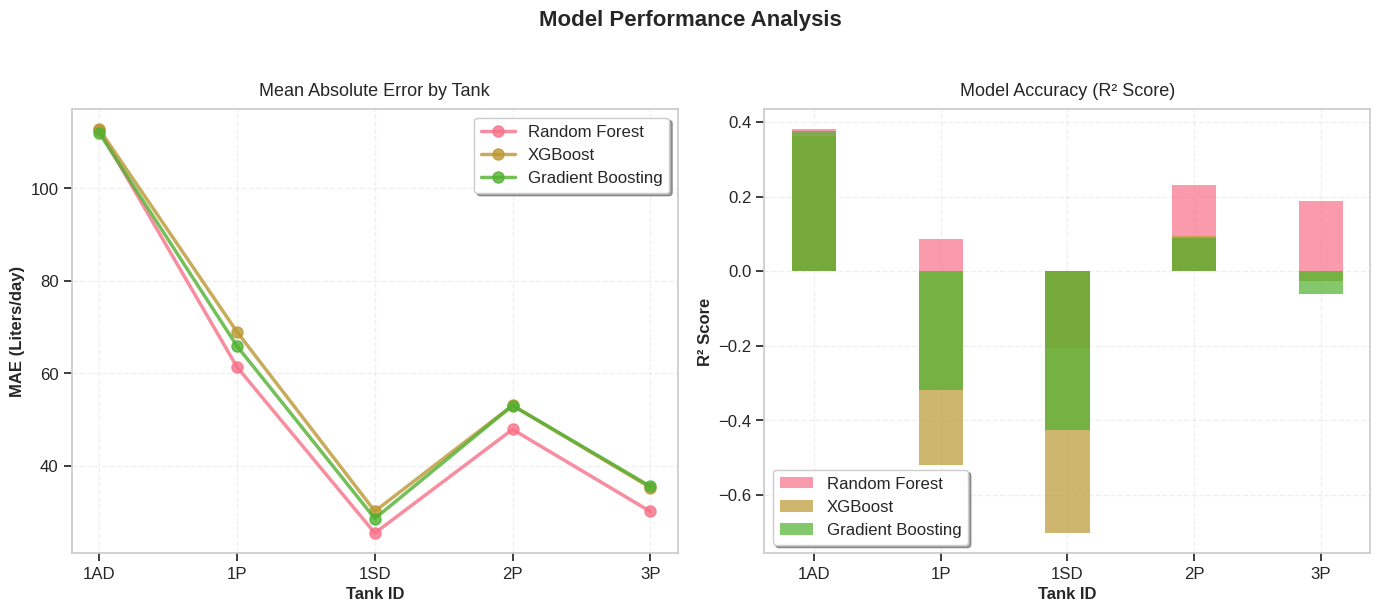


📊 Figure 1: Model Performance Comparison



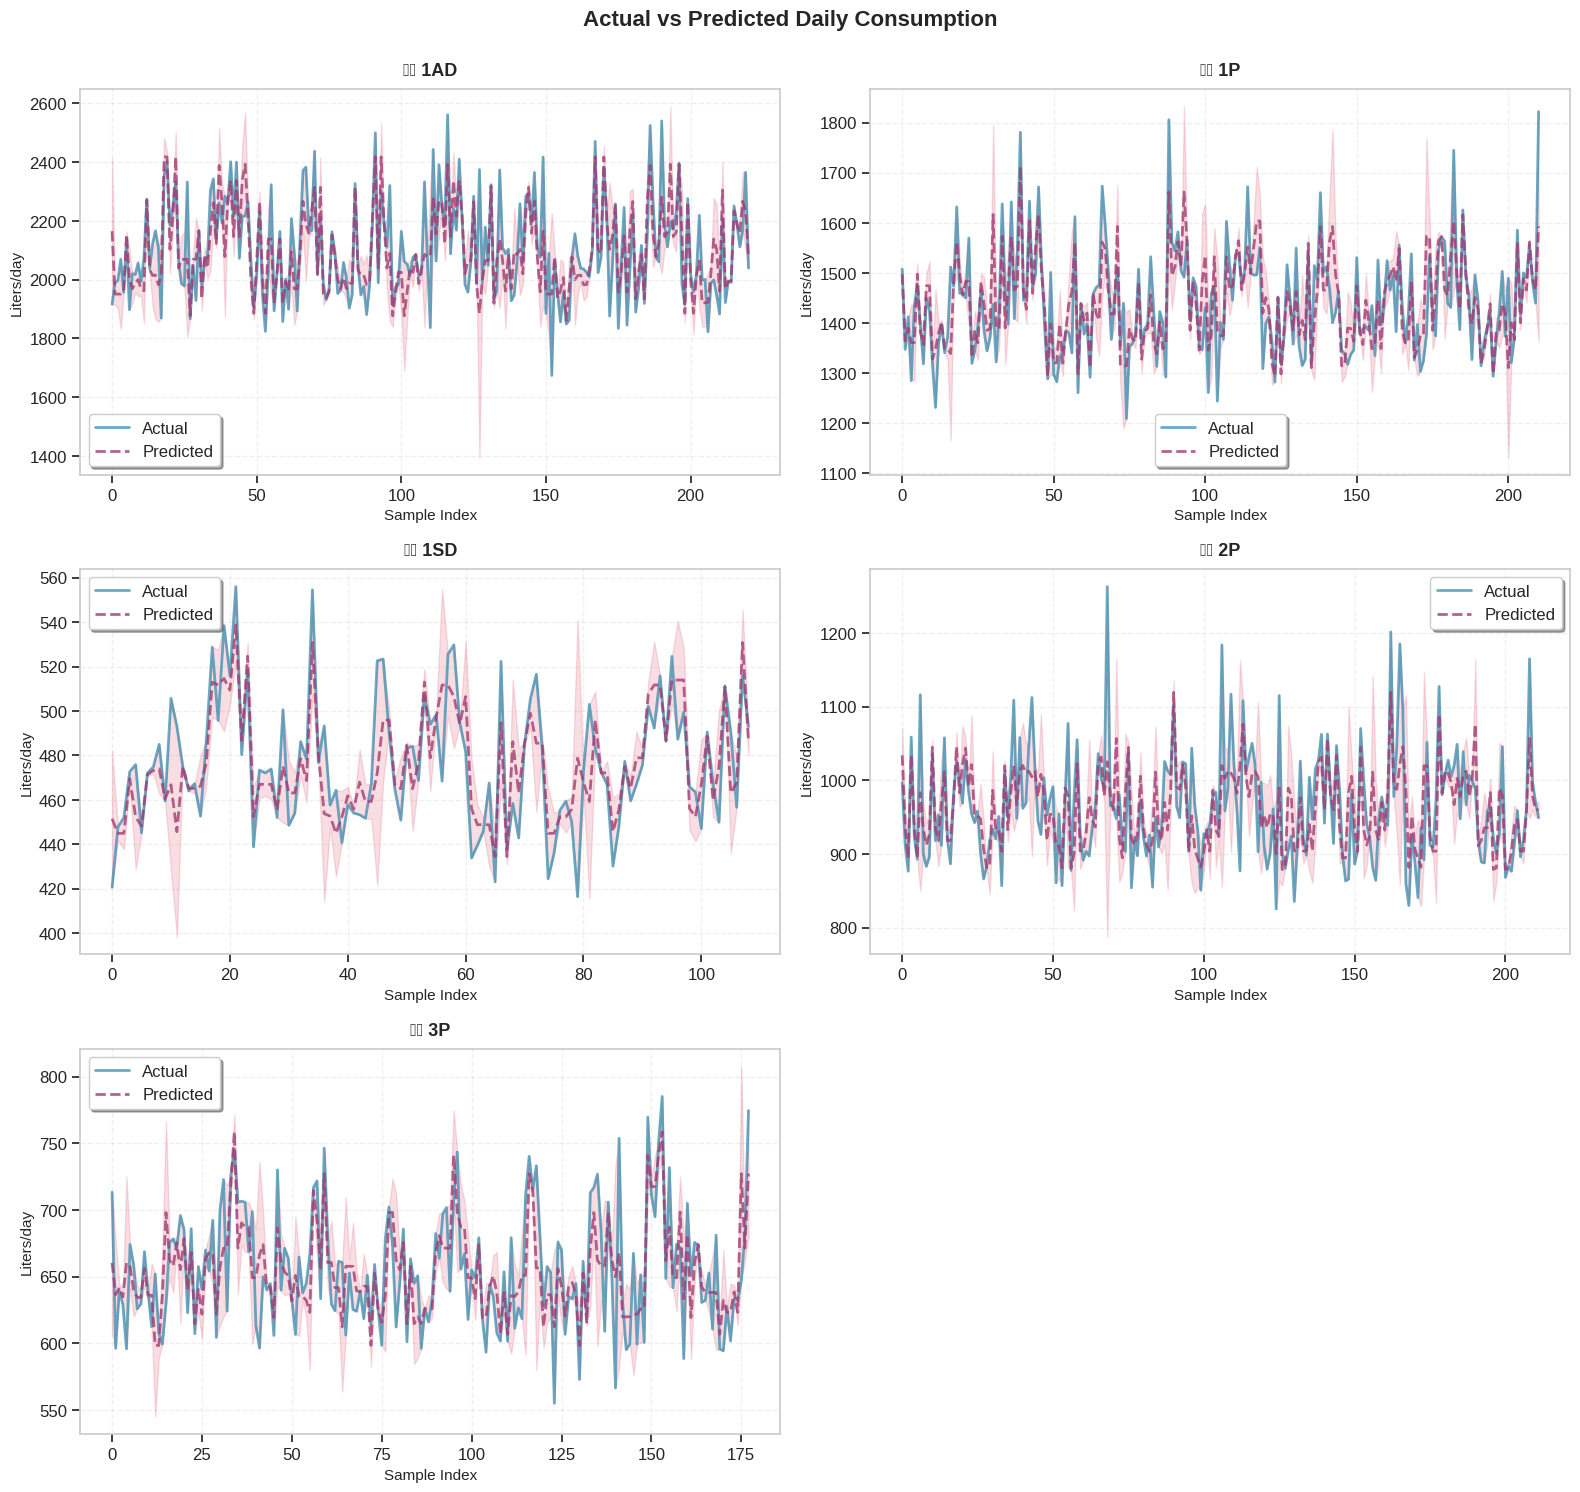


📈 Figure 2: Prediction Performance by Tank



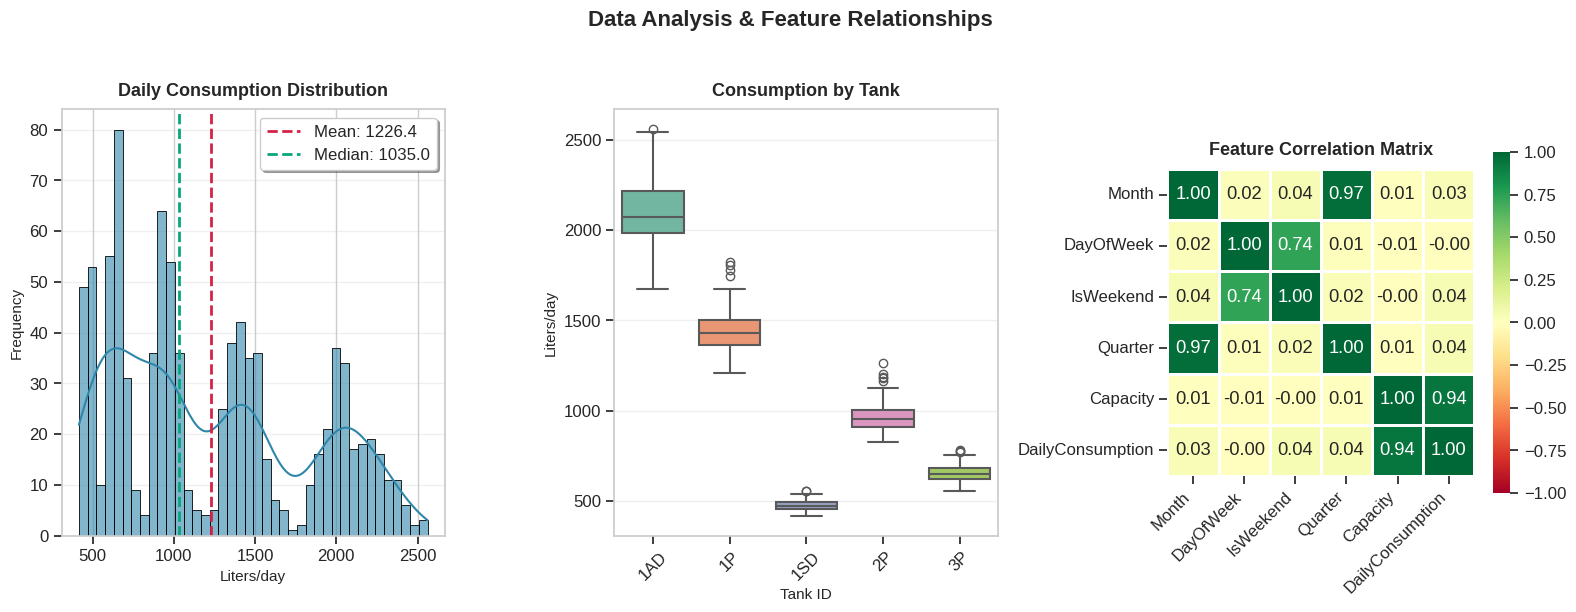


📊 Figure 3: Distribution & Correlation Analysis



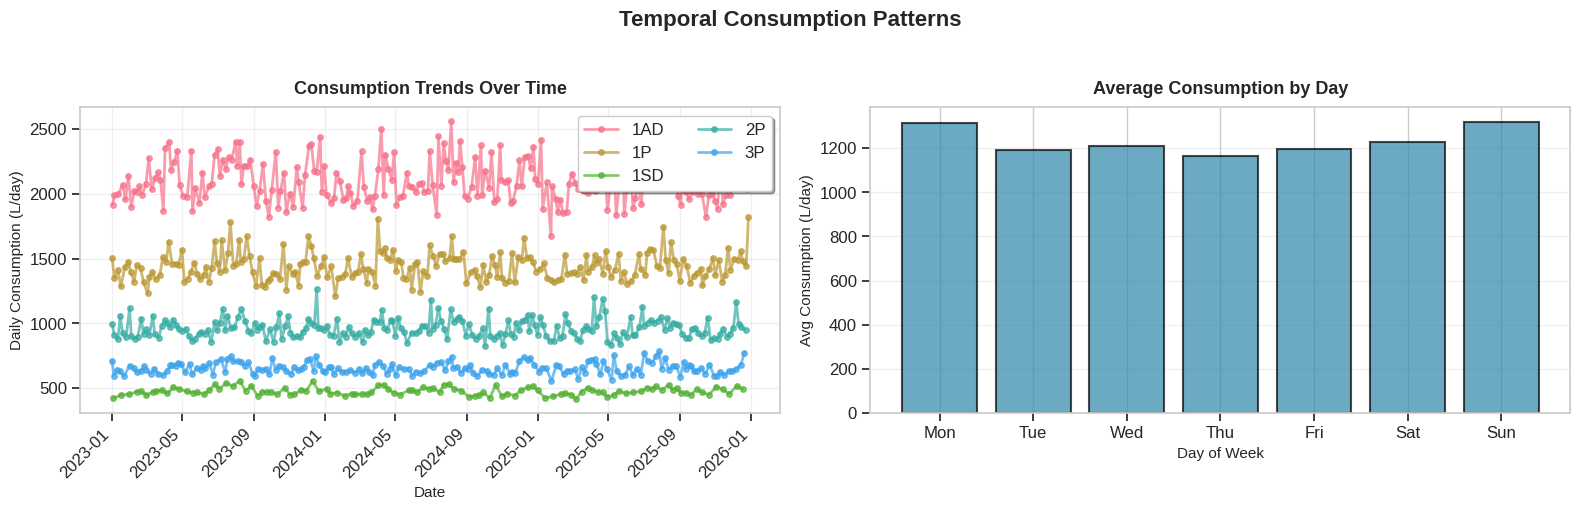


📅 Figure 4: Temporal Analysis


📋 SUMMARY STATISTICS
       DailyConsumption                                                      \
                  count     mean     std     min      25%      50%      75%   
TankID                                                                        
1AD               221.0  2104.47  165.43  1674.0  1985.67  2072.50  2215.33   
1P                211.0  1439.95  105.49  1209.4  1363.07  1431.33  1501.32   
1SD               109.0   476.53   29.07   416.4   454.09   473.43   493.33   
2P                212.0   963.59   74.75   825.5   909.79   953.67  1006.47   
3P                178.0   655.19   44.25   555.0   624.29   650.58   680.48   

                 
            max  
TankID           
1AD     2561.25  
1P      1822.00  
1SD      556.00  
2P      1262.67  
3P       785.25  



In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
sns.set_palette("husl")

colors = {
    'primary': '#2E86AB',
    'secondary': '#A23B72',
    'accent': '#F18F01',
    'success': '#06A77D',
    'warning': '#D62246'
}

# Figure 1: Model Performance Comparison

fig1 = plt.figure(figsize=(14, 6))
fig1.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold', y=1.02)

# Subplot 1: MAE Comparison
ax1 = plt.subplot(1, 2, 1)
for idx, model_name in enumerate(results_df["Model"].unique()):
    subset = results_df[results_df["Model"] == model_name]
    ax1.plot(subset["Tank"], subset["MAE"], marker="o", linewidth=2.5,
             markersize=8, label=model_name, alpha=0.8)
ax1.set_xlabel("Tank ID", fontsize=12, fontweight='bold')
ax1.set_ylabel("MAE (Liters/day)", fontsize=12, fontweight='bold')
ax1.set_title("Mean Absolute Error by Tank", fontsize=13, pad=10)
ax1.legend(frameon=True, shadow=True, fancybox=True)
ax1.grid(True, alpha=0.3, linestyle='--')

# Subplot 2: R² Score Comparison (if available in results_df)
ax2 = plt.subplot(1, 2, 2)
if "R2" in results_df.columns:
    for idx, model_name in enumerate(results_df["Model"].unique()):
        subset = results_df[results_df["Model"] == model_name]
        ax2.bar(subset["Tank"], subset["R2"], alpha=0.7, label=model_name, width=0.35)
    ax2.set_xlabel("Tank ID", fontsize=12, fontweight='bold')
    ax2.set_ylabel("R² Score", fontsize=12, fontweight='bold')
    ax2.set_title("Model Accuracy (R² Score)", fontsize=13, pad=10)
    ax2.legend(frameon=True, shadow=True)
else:
    # Alternative: RMSE comparison
    for idx, model_name in enumerate(results_df["Model"].unique()):
        subset = results_df[results_df["Model"] == model_name]
        ax2.plot(subset["Tank"], subset.get("RMSE", subset["MAE"]),
                marker="s", linewidth=2.5, markersize=8, label=model_name, alpha=0.8)
    ax2.set_xlabel("Tank ID", fontsize=12, fontweight='bold')
    ax2.set_ylabel("RMSE (Liters/day)", fontsize=12, fontweight='bold')
    ax2.set_title("Root Mean Squared Error", fontsize=13, pad=10)
    ax2.legend(frameon=True, shadow=True)

ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 Figure 1: Model Performance Comparison")
print("="*60 + "\n")


# Figure 2: Actual vs Predicted (Grid Layout)

tank_ids = df_clean["TankID"].unique()
n_tanks = len(tank_ids)
n_cols = 2
n_rows = int(np.ceil(n_tanks / n_cols))

fig2 = plt.figure(figsize=(16, 5*n_rows))
fig2.suptitle('Actual vs Predicted Daily Consumption', fontsize=16, fontweight='bold', y=0.995)

for i, tank_id in enumerate(tank_ids):
    model = tank_models[tank_id]
    scaler = tank_scalers[tank_id]
    tank_data = df_clean[df_clean["TankID"] == tank_id]

    X = tank_data[features]
    y = tank_data[target]
    X_scaled = scaler.transform(X)
    y_pred = model.predict(X_scaled)

    ax = plt.subplot(n_rows, n_cols, i+1)

    # Plot with better styling
    ax.plot(y.values, label="Actual", linewidth=2, color=colors['primary'], alpha=0.7)
    ax.plot(y_pred, label="Predicted", linewidth=2, color=colors['secondary'],
            linestyle='--', alpha=0.8)

    # Add shaded error region
    error = np.abs(y.values - y_pred)
    ax.fill_between(range(len(y)), y_pred - error, y_pred + error,
                     alpha=0.15, color=colors['warning'])

    ax.set_title(f"🛢️ {tank_id}", fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Sample Index", fontsize=11)
    ax.set_ylabel("Liters/day", fontsize=11)
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📈 Figure 2: Prediction Performance by Tank")
print("="*60 + "\n")

# Figure 3: Data Distribution & Correlation

fig3 = plt.figure(figsize=(16, 6))
fig3.suptitle('Data Analysis & Feature Relationships', fontsize=16, fontweight='bold', y=1.02)

# Subplot 1: Distribution of Daily Consumption
ax1 = plt.subplot(1, 3, 1)
sns.histplot(df_clean["DailyConsumption"], bins=40, kde=True,
             color=colors['primary'], alpha=0.6, edgecolor='black', ax=ax1)
ax1.axvline(df_clean["DailyConsumption"].mean(), color=colors['warning'],
            linestyle='--', linewidth=2, label=f'Mean: {df_clean["DailyConsumption"].mean():.1f}')
ax1.axvline(df_clean["DailyConsumption"].median(), color=colors['success'],
            linestyle='--', linewidth=2, label=f'Median: {df_clean["DailyConsumption"].median():.1f}')
ax1.set_title("Daily Consumption Distribution", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Liters/day", fontsize=11)
ax1.set_ylabel("Frequency", fontsize=11)
ax1.legend(frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, axis='y')

# Subplot 2: Box Plot by Tank
ax2 = plt.subplot(1, 3, 2)
sns.boxplot(data=df_clean, x="TankID", y="DailyConsumption",
            palette="Set2", ax=ax2, linewidth=1.5)
ax2.set_title("Consumption by Tank", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel("Tank ID", fontsize=11)
ax2.set_ylabel("Liters/day", fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Subplot 3: Feature Correlation Heatmap
ax3 = plt.subplot(1, 3, 3)
corr_matrix = df_clean[features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax3, vmin=-1, vmax=1)
ax3.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold', pad=10)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax3.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 Figure 3: Distribution & Correlation Analysis")
print("="*60 + "\n")

# Figure 4: Time-based Analysis (if LoadDate available)

if "LoadDate" in df_clean.columns:
    fig4 = plt.figure(figsize=(16, 5))
    fig4.suptitle('Temporal Consumption Patterns', fontsize=16, fontweight='bold', y=1.02)

    # Subplot 1: Consumption over time by tank
    ax1 = plt.subplot(1, 2, 1)
    for tank_id in tank_ids:
        tank_subset = df_clean[df_clean["TankID"] == tank_id].sort_values("LoadDate")
        ax1.plot(tank_subset["LoadDate"], tank_subset["DailyConsumption"],
                marker='o', linewidth=2, markersize=4, label=tank_id, alpha=0.7)
    ax1.set_title("Consumption Trends Over Time", fontsize=13, fontweight='bold', pad=10)
    ax1.set_xlabel("Date", fontsize=11)
    ax1.set_ylabel("Daily Consumption (L/day)", fontsize=11)
    ax1.legend(frameon=True, shadow=True, ncol=2)
    ax1.grid(True, alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Subplot 2: Average consumption by day of week (if DayOfWeek feature exists)
    ax2 = plt.subplot(1, 2, 2)
    if "DayOfWeek" in df_clean.columns:
        day_avg = df_clean.groupby("DayOfWeek")["DailyConsumption"].mean().sort_index()
        days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        ax2.bar(range(len(day_avg)), day_avg.values, color=colors['primary'],
                alpha=0.7, edgecolor='black', linewidth=1.5)
        ax2.set_xticks(range(len(day_avg)))
        ax2.set_xticklabels(days[:len(day_avg)])
        ax2.set_title("Average Consumption by Day", fontsize=13, fontweight='bold', pad=10)
        ax2.set_xlabel("Day of Week", fontsize=11)
        ax2.set_ylabel("Avg Consumption (L/day)", fontsize=11)
        ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("📅 Figure 4: Temporal Analysis")
    print("="*60 + "\n")


# Summary Statistics Table

print("\n" + "="*80)
print("📋 SUMMARY STATISTICS")
print("="*80)
print(df_clean[["TankID", "DailyConsumption"]].groupby("TankID").describe().round(2))
print("="*80 + "\n")

# 12.Save Best Models

In [ ]:
import pickle

model_package = {
    "models": models,
    "scalers": scalers,
    "metrics": results_df,
    "tank_capacities": tank_capacities,
    "features": features
}

with open("ftms_ml_models.pkl", "wb") as f:
    pickle.dump(model_package, f)

files.download("ftms_ml_models.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
metrics_dict = {
    row["Tank"]: {
        "mae": row["MAE"],
        "rmse": row["RMSE"],
        "r2": row["R2"]
    }
    for _, row in results_df.iterrows()
}

model_package = {
    "consumption_models": tank_models,
    "consumption_scalers": tank_scalers,
    "consumption_metrics": metrics_dict,
    "tank_capacities": tank_capacities,
    "feature_columns": features
}

with open("ftms_ml_models.pkl", "wb") as f:
    pickle.dump(model_package, f)

files.download("ftms_ml_models.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#13.Prediction Function

In [ ]:
def predict_days_until_empty(tank_id, current_fuel, prediction_date=None):

    if tank_id not in tank_models:
        return {"error": "Invalid Tank ID"}

    capacity = tank_capacities[tank_id]
    if current_fuel <= 0 or current_fuel > capacity:
        return {"error": f"Invalid fuel level (0-{capacity})"}

    if prediction_date is None:
        prediction_date = datetime.now()

    # Prepare input features
    X_input = pd.DataFrame([{
        'Month': prediction_date.month,
        'DayOfWeek': prediction_date.weekday(),
        'IsWeekend': int(prediction_date.weekday() >= 5),
        'Quarter': (prediction_date.month - 1) // 3 + 1,
        'Capacity': capacity
    }])

    # Use best tank model and scaler
    scaler = tank_scalers[tank_id]
    model = tank_models[tank_id]

    X_scaled = scaler.transform(X_input)
    daily_rate = model.predict(X_scaled)[0]
    daily_rate = max(daily_rate, 1)  # safety

    days_until_empty = current_fuel / daily_rate
    empty_date = prediction_date + timedelta(days=int(days_until_empty))

    return {
        'tank_id': tank_id,
        'current_fuel': current_fuel,
        'predicted_daily_consumption': round(daily_rate, 2),
        'days_until_empty': round(days_until_empty, 2),
        'estimated_empty_date': empty_date.strftime('%Y-%m-%d')
    }

print("✓ Prediction function ready!")


✓ Prediction function ready!


#14.Test Predictions

In [ ]:
test_cases = [
    ('1P', 1000),
    ('2P', 1000),
    ('3P', 1000),
    ('1AD', 1000),
    ('1SD', 1000),
]

for tank, level in test_cases:
    result = predict_days_until_empty(tank, level)
    if "error" in result:
        print(f"{tank} | Error: {result['error']}")
    else:
        print(f"{tank} | Current: {level}L | Days until empty: {result['days_until_empty']} | Empty date: {result['estimated_empty_date']}")


1P | Current: 1000L | Days until empty: 0.72 | Empty date: 2026-02-19
2P | Current: 1000L | Days until empty: 1.1 | Empty date: 2026-02-20
3P | Current: 1000L | Days until empty: 1.56 | Empty date: 2026-02-20
1AD | Current: 1000L | Days until empty: 0.54 | Empty date: 2026-02-19
1SD | Current: 1000L | Days until empty: 2.19 | Empty date: 2026-02-21


In [ ]:
test_cases = [
    ('1P', 9000),
    ('2P', 7000),
    ('3P', 6000),
    ('1AD', 5200),
    ('1SD', 3000),
]

for tank, level in test_cases:
    result = predict_days_until_empty(tank, level)
    if "error" in result:
        print(f"{tank} | Error: {result['error']}")
    else:
        print(f"{tank} | Current: {level}L | Days until empty: {result['days_until_empty']} | Empty date: {result['estimated_empty_date']}")

1P | Current: 9000L | Days until empty: 6.51 | Empty date: 2026-02-25
2P | Current: 7000L | Days until empty: 7.67 | Empty date: 2026-02-26
3P | Current: 6000L | Days until empty: 9.33 | Empty date: 2026-02-28
1AD | Current: 5200L | Days until empty: 2.79 | Empty date: 2026-02-21
1SD | Current: 3000L | Days until empty: 6.58 | Empty date: 2026-02-25


In [ ]:
import sklearn
import xgboost
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)


sklearn: 1.6.1
xgboost: 3.1.2


In [ ]:
import numpy as np
print(np.__version__)


1.26.4
